## 1. What this notebook computes

The *Clifford algebra* Cl(4,4) of the author's space-time is the set of all real
linear combinations of products of his eight gamma matrices
$\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$. This notebook shows, exactly, that it is the
set of ALL real $16 \times 16$ matrices, and why 16 is the smallest size that eight
such matrices can have. It

- forms the 256 ordered products $\gamma_A$, one for each set $A$ of directions, and
  counts them by their number of factors;
- checks the three rules by which the products multiply, square and pass each other,
  for all pairs; draws the multiplication table of the 16 products of the first
  four gammas;
- finds which products square to $+I_{16}$ (136, the symmetric ones) and which to
  $-I_{16}$ (120, the antisymmetric ones);
- checks the *trace lemma* (every product except $I_{16}$ has trace 0) and that the
  256 products are perpendicular to each other in the trace sense;
- proves that they are linearly independent (exact rank 256 = $16^2$) and writes
  any matrix as a combination of them;
- shows that the 128 even products fill the two diagonal $8 \times 8$ blocks and the
  128 odd ones the two other blocks;
- compares four examples to show why the matrices must be at least $16 \times 16$;
- shows the 28 products of two different gammas, half of which are the matrices
  $S^{ab}$ of the Revision record, and compares them entry by entry with the record;
- reproduces the Revision record of these facts and draws eight figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 04c (The 256 products of the author's gammas: Cl(4,4) is all real 16 by 16
matrices) is the file `Revision/textbook/notebooks/04c_256_products.ipynb` of the
repository Dirac_claude. It forms the 256 ordered products of the author's eight gammas,
checks exactly the three rules by which they multiply, their squares and symmetry (136
symmetric, 120 antisymmetric), the trace lemma and their orthogonality, proves that they
are linearly independent (exact rank 256), so that the Clifford algebra Cl(4,4) is the
set of all real 16 by 16 matrices, writes any matrix as a combination of them, shows that
the 128 even products fill the two diagonal 8 by 8 blocks, explains why 16 is the
smallest possible size, reproduces the Revision record of these facts, checks that half
of each product of two different gammas is the matrix S of the Revision record, and draws
eight figures. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 04c_256_products.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 04c_256_products.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
04c_256_products.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/04c.captions.json`
- `Revision/textbook/figures/04c_1_products_by_degree.png`
- `Revision/textbook/figures/04c_2_multiplication_table.png`
- `Revision/textbook/figures/04c_3_squares_by_degree.png`
- `Revision/textbook/figures/04c_4_trace_products.png`
- `Revision/textbook/figures/04c_5_coefficients.png`
- `Revision/textbook/figures/04c_6_even_odd_blocks.png`
- `Revision/textbook/figures/04c_7_how_big.png`
- `Revision/textbook/figures/04c_8_two_gamma_products.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all eight figure files exist
    ALL 19 CHECKS PASSED (notebook 04c)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/04c_256_products.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 04c_256_products.ipynb
      python -m nbconvert --execute --inplace 04c_256_products.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `Revision/algebra/gammas.json` or for a file in
  `Revision/algebra/reports`: the notebook reads these Revision record files of the
  repository; they are part of every complete clone. Run `git status` in the repository
  folder: if it reports them as deleted, restore them with the command below and run the
  notebook again.

      git checkout HEAD Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 04c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 04c (The 256 products of the author's gammas: Cl(4,4) is all real 16 by 16
# matrices) is the file Revision/textbook/notebooks/04c_256_products.ipynb of the
# repository Dirac_claude. It forms the 256 ordered products of the author's eight
# gammas, checks exactly the three rules by which they multiply, their squares and
# symmetry (136 symmetric, 120 antisymmetric), the trace lemma and their orthogonality,
# proves that they are linearly independent (exact rank 256), so that the Clifford
# algebra Cl(4,4) is the set of all real 16 by 16 matrices, writes any matrix as a
# combination of them, shows that the 128 even products fill the two diagonal 8 by 8
# blocks, explains why 16 is the smallest possible size, reproduces the Revision record
# of these facts, checks that half of each product of two different gammas is the matrix
# S of the Revision record, and draws eight figures. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 04c_256_products.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 04c_256_products.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 04c_256_products.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/04c.captions.json
# - Revision/textbook/figures/04c_1_products_by_degree.png
# - Revision/textbook/figures/04c_2_multiplication_table.png
# - Revision/textbook/figures/04c_3_squares_by_degree.png
# - Revision/textbook/figures/04c_4_trace_products.png
# - Revision/textbook/figures/04c_5_coefficients.png
# - Revision/textbook/figures/04c_6_even_odd_blocks.png
# - Revision/textbook/figures/04c_7_how_big.png
# - Revision/textbook/figures/04c_8_two_gamma_products.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all eight figure files exist
#     ALL 19 CHECKS PASSED (notebook 04c)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/04c_256_products.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 04c_256_products.ipynb
#     python -m nbconvert --execute --inplace 04c_256_products.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or for a file in
#   Revision/algebra/reports: the notebook reads these Revision record files of the
#   repository; they are part of every complete clone. Run git status in the repository
#   folder: if it reports them as deleted, restore them with the command below and run
#   the notebook again.
#     git checkout HEAD Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "04c"  # this notebook: chapter 04, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 04c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Set, subset**: a set is a collection of different objects, written in braces,
  for example $A = \{x_2, x_5\}$; a *subset* of a set $S$ is a set whose elements all
  belong to $S$. The empty set $\{\}$ has no element.
- **Binomial coefficient** $\binom{n}{k}$ ("n choose k"): the number of subsets with
  $k$ elements of a set with $n$ elements; $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ with
  $n! = 1 \cdot 2 \cdots n$ and $0! = 1$. For example $\binom{8}{2} = 28$.
- **Product** $\gamma_A$: for a set $A$ of directions, the product of their gamma
  matrices in increasing order, for example
  $\gamma_{\{x_2, x_5\}} = \gamma^{(x_2)}\gamma^{(x_5)}$; for the empty set,
  $\gamma_{\{\}} = I_{16}$. Its **degree** is the number $k$ of factors; the product
  is **even** if $k$ is even and **odd** if $k$ is odd.
- **Symmetric difference** $A \triangle B$: the directions that lie in exactly one of
  the sets $A$ and $B$.
- **Linear combination**: $c_1 M_1 + c_2 M_2 + \dots$ with numbers $c_j$. Matrices
  are **linearly independent** if the only combination that gives the zero matrix
  has all $c_j = 0$. The **span** of a list of matrices is the set of all their
  combinations; a **basis** of a space is an independent list that spans it, and the
  number of its elements is the **dimension** of the space. All real $16 \times 16$
  matrices form a space of dimension $16 \times 16 = 256$ (one number per entry).
- **Rank** of a list of matrices: the largest number of independent matrices in it,
  which is the dimension of its span. sympy computes it exactly with fractions.
- **Trace** $\mathrm{tr}\,M$: the sum of the diagonal entries. It has the *cyclic
  property* $\mathrm{tr}(MN) = \mathrm{tr}(NM)$, because both are
  $\sum_{i,j} M_{ij}N_{ji}$.
- **Orthogonal matrix**: $M^T M = I$, so $M^{-1} = M^T$.
- **Block diagonal**: a $16 \times 16$ matrix whose upper-right and lower-left
  $8 \times 8$ blocks are zero; **block off-diagonal**: one whose upper-left and
  lower-right blocks are zero.
- **Clifford algebra** Cl(4,4): the set of all real combinations of products of
  eight matrices that satisfy the Clifford relation with four signs $+1$ and four
  signs $-1$.

## 4. The physical and mathematical situation

The author's gammas satisfy the Clifford relation
$\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}I_{16}$ with
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order of his coordinates
$x_1, \dots, x_8$: space-like 3-space $x_1, x_2, x_3$ and hidden direction $x_8$,
time-like time $x_4$ and extra times $x_5, x_6, x_7$ (the extra times deflate
exponentially in his metric; the gammas, which belong to the local frame, are
constant). Everything below follows from this relation alone; the computer checks
each rule for the author's matrices.

**Rule R1 (products multiply into products).** Two different gammas anticommute and
$\gamma^a\gamma^a = \eta^{aa}I_{16}$. To multiply $\gamma_A\gamma_B$, move each factor
of $\gamma_B$ to the left until it reaches its place in increasing order. Passing a
different gamma gives a factor $-1$; meeting the same gamma gives $\eta^{aa}$. So
$\gamma_A\gamma_B = s(A,B)\,\gamma_{A\triangle B}$ with the sign
$s(A,B) = (-1)^{N(A,B)}\prod_{c \in A\cap B}\eta^{cc}$, where $N(A,B)$ is the number of
pairs $(a, b)$ with $a$ in $A$, $b$ in $B$ and $a$ later than $b$.

**Rule R2 (squares).** By R1 with $B = A$:
$\gamma_A\gamma_A = (-1)^{k(k-1)/2}\prod_{a\in A}\eta^{aa}\,I_{16}$ for a product of
degree $k$ (here $N(A,A) = k(k-1)/2$, the number of pairs in $A$).

**Rule R3 (passing one gamma).** Moving $\gamma^b$ from the left of $\gamma_A$ to its
right passes each of the $k$ factors once: $\gamma^b\gamma_A = (-1)^k\gamma_A\gamma^b$
if $b$ is not in $A$ and $(-1)^{k-1}\gamma_A\gamma^b$ if it is.

**The trace lemma.** For eight gammas (an even number) every $\gamma_A$ with $A$ not
empty has trace 0. Proof, line by line: if $k$ is odd, then $k \le 7$, so some $b$ is
not in $A$, and R3 gives $\gamma^b\gamma_A = -\gamma_A\gamma^b$; if $k$ is even, take
$b$ in $A$, and R3 gives again $\gamma^b\gamma_A = -\gamma_A\gamma^b$. Multiply from
the left by $(\gamma^b)^{-1} = \eta^{bb}\gamma^b$:
$\gamma_A = -(\gamma^b)^{-1}\gamma_A\gamma^b$. Take the trace and use the cyclic
property: $\mathrm{tr}\,\gamma_A = -\mathrm{tr}(\gamma_A\gamma^b(\gamma^b)^{-1})
= -\mathrm{tr}\,\gamma_A$. A number equal to its negative is 0.

**Independence.** Each $\gamma_A$ is a product of orthogonal matrices, hence
orthogonal: $\gamma_A^T = \gamma_A^{-1} = \pm\gamma_A$ (the sign of R2). So
$\gamma_A^T\gamma_B = \pm\gamma_A\gamma_B = \pm\gamma_{A\triangle B}$ (R1), whose trace
is 0 unless $A = B$ (trace lemma), and $\mathrm{tr}(\gamma_A^T\gamma_A) =
\mathrm{tr}\,I_{16} = 16$. If $\sum_B c_B\gamma_B = 0$, multiply by $\gamma_A^T$ and
take the trace: $16\,c_A = 0$. So all coefficients vanish: the 256 products are
independent. Since the real $16 \times 16$ matrices form a space of dimension
$256$, the products are a basis of it: **Cl(4,4) is all real $16 \times 16$
matrices**, and every matrix $M$ is $\sum_A c_A\gamma_A$ with
$c_A = \mathrm{tr}(\gamma_A^T M)/16$.

**How big.** The same argument works for any even number $n$ of $d \times d$ matrices
with a Clifford relation, real or complex, if $\gamma_A^{-1}$ is used in place of
$\gamma_A^T$: by R2 every product squares to $\pm 1$, so $\gamma_A^{-1} = \pm\gamma_A$,
and $\mathrm{tr}(\gamma_A^{-1}\gamma_B)$ is 0 for $A \neq B$ and $d$ for $A = B$. So
the $2^n$ products are independent and must fit into the space of all $d \times d$
matrices, of dimension $d^2$: $d^2 \ge 2^n$. For $n = 8$: $d \ge 16$. A field on
which eight gammas act therefore has at least 16 components; the author's field
has exactly 16.

## 5. The 256 products

The next cell reads the gammas from the Revision record file
`Revision/algebra/gammas.json` (eight matrices in the order $x_1, \dots, x_8$, whole
numbers), then forms the 256 products. `itertools.combinations(range(8), k)` lists the
sets of $k$ directions in increasing order (direction index 0 is $x_1$, ..., 7 is
$x_8$), for $k = 0, 1, \dots, 8$, which is also the order of the Revision verifier.
The products are kept in one numpy array `products` of shape (256, 16, 16): product
number $i$ is `products[i]`. The cell then counts the products of each degree and
compares with the binomial coefficients $\binom{8}{k}$.

In [2]:
import itertools  # all subsets of a given size
from math import comb  # comb(n, k) is the binomial coefficient n choose k

import numpy as np
import sympy as sp
from matplotlib.colors import BoundaryNorm, ListedColormap
from sympy.polys.matrices import DomainMatrix  # exact matrices for the rank

record = json.loads(repository_file("Revision/algebra/gammas.json")
                    .read_text(encoding="utf-8"))
eta = record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1] in the order x1..x8
gamma = [np.array(matrix, dtype=np.int64) for matrix in record["gamma"]]
I16 = np.eye(16, dtype=np.int64)

SETS = [s for k in range(9) for s in itertools.combinations(range(8), k)]
INDEX = {s: i for i, s in enumerate(SETS)}  # set -> its number in the list
products = np.zeros((256, 16, 16), dtype=np.int64)
for i, s in enumerate(SETS):
    matrix = I16
    for a in s:  # multiply the gammas of the set in increasing order
        matrix = matrix @ gamma[a]
    products[i] = matrix
DEGREE = np.array([len(s) for s in SETS])  # the number of factors of each product


def label(s):
    """A short name of a set: its coordinate numbers, e.g. (1, 4) -> "25"."""
    return "".join(str(a + 1) for a in s) if s else "I"


counts = [int(np.sum(DEGREE == k)) for k in range(9)]
report("number of products of degree 0, 1, ..., 8", counts)
report("even and odd products", (sum(counts[0::2]), sum(counts[1::2])))
check(counts == [comb(8, k) for k in range(9)] and sum(counts) == 256
      and sum(counts[0::2]) == 128,
      "the products by degree are 1, 8, 28, 56, 70, 56, 28, 8, 1 (128 even)")

RESULT number of products of degree 0, 1, ..., 8 = [1, 8, 28, 56, 70, 56, 28, 8, 1]
RESULT even and odd products = (128, 128)
PASS the products by degree are 1, 8, 28, 56, 70, 56, 28, 8, 1 (128 even)


The next cell draws these numbers as a bar chart, even degrees in one colour and odd
degrees in another, with each number written above its bar.

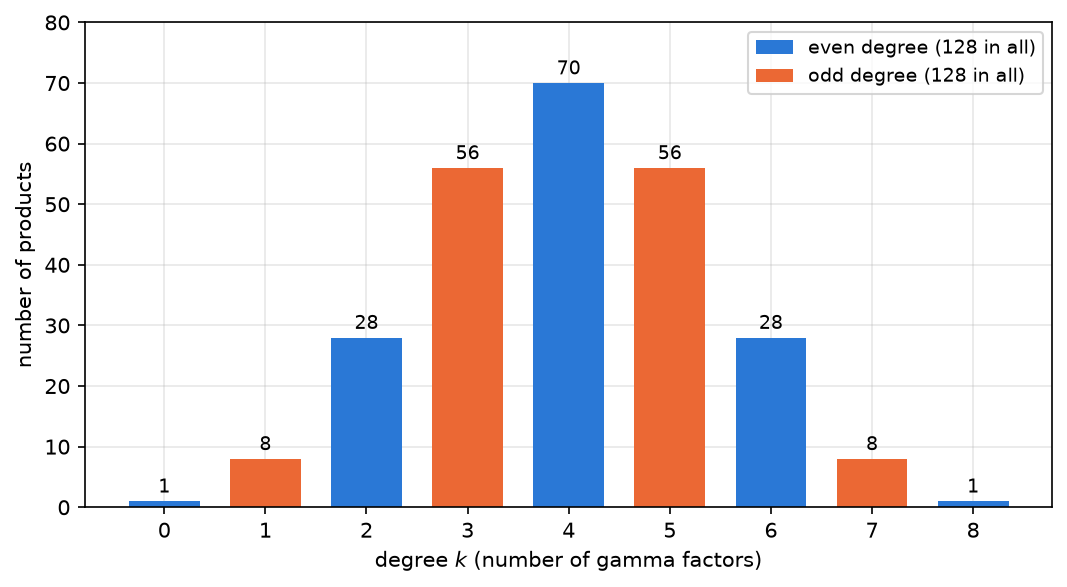

Figure 04c.1 saved as Revision/textbook/figures/04c_1_products_by_degree.png


In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
ax.set_axisbelow(True)  # grid lines behind the bars
colours = ["#2a78d6" if k % 2 == 0 else "#eb6834" for k in range(9)]
bars = ax.bar(range(9), counts, color=colours, width=0.7)
ax.bar_label(bars, labels=[str(n) for n in counts], padding=2, fontsize=9)
ax.set_xticks(range(9))
ax.set_xlabel("degree $k$ (number of gamma factors)")
ax.set_ylabel("number of products")
ax.set_ylim(0, 80)
ax.legend(handles=[bars[0], bars[1]], labels=["even degree (128 in all)",
                                             "odd degree (128 in all)"], fontsize=9)
save_figure(fig, "products_by_degree",
            "The 256 ordered products of the author's eight gammas, counted by their "
            "degree $k$, the number of gamma factors (horizontal axis $k$ from 0 to "
            "8, vertical axis the number of products). The counts are the binomial "
            "coefficients $\\binom{8}{k}$ = 1, 8, 28, 56, 70, 56, 28, 8, 1; the even "
            "degrees (blue) and the odd degrees (orange) contribute 128 products "
            "each.")

## 6. Rule R1: the products multiply into products

The next cell multiplies every product with every product (256 times 256 = 65536
multiplications; `products[i] @ products` multiplies product $i$ with all 256 at
once) and checks that each result is $+\gamma_{A\triangle B}$ or
$-\gamma_{A\triangle B}$, with exactly the sign $s(A,B)$ of rule R1. It also checks
that every product is a signed permutation matrix (one entry $\pm 1$ in each row and
column), hence orthogonal.

In [4]:
def sign_formula(A, B):
    """s(A, B) of rule R1: (-1)^N(A, B) times the signs eta of the common directions."""
    later_pairs = sum(1 for a in A for b in B if a > b)  # N(A, B)
    sign = (-1) ** later_pairs
    for c in set(A) & set(B):  # & : the directions in both sets
        sign *= eta[c]
    return sign


rule_r1 = True
SIGN = np.zeros((256, 256), dtype=np.int64)  # SIGN[i, j] = s(A_i, A_j)
for i, A in enumerate(SETS):
    row = products[i] @ products  # gamma_A times each of the 256 products
    for j, B in enumerate(SETS):
        target = products[INDEX[tuple(sorted(set(A) ^ set(B)))]]  # ^ : symmetric diff.
        SIGN[i, j] = sign_formula(A, B)
        rule_r1 &= bool((row[j] == SIGN[i, j] * target).all())
report("pairs with sign +1 and with sign -1",
       (int(np.sum(SIGN == 1)), int(np.sum(SIGN == -1))))
check(rule_r1, "gamma_A gamma_B = s(A,B) gamma_(A sym. diff. B) for all 65536 pairs")
signed_permutations = all(
    (np.count_nonzero(m, axis=0) == 1).all() and (np.count_nonzero(m, axis=1) == 1).all()
    and set(np.unique(m)) <= {-1, 0, 1} for m in products[1:])  # <= : subset
check(signed_permutations and all((m.T @ m == I16).all() for m in products),
      "every product is a signed permutation matrix, hence orthogonal")

RESULT pairs with sign +1 and with sign -1 = (33280, 32256)
PASS gamma_A gamma_B = s(A,B) gamma_(A sym. diff. B) for all 65536 pairs
PASS every product is a signed permutation matrix, hence orthogonal


The next cell draws the multiplication table of the 16 products of the first four
gammas $\gamma^{(x_1)}, \gamma^{(x_2)}, \gamma^{(x_3)}, \gamma^{(x_4)}$ (the three
directions of 3-space and the time): row $\gamma_A$, column $\gamma_B$, and in the
square the name of $A \triangle B$ (the coordinate numbers, I for the identity), red
for the sign $+1$ and blue for $-1$. The 16 products of four gammas multiply among
themselves; this is the Clifford algebra of four directions, the algebra of Dirac's
matrices.

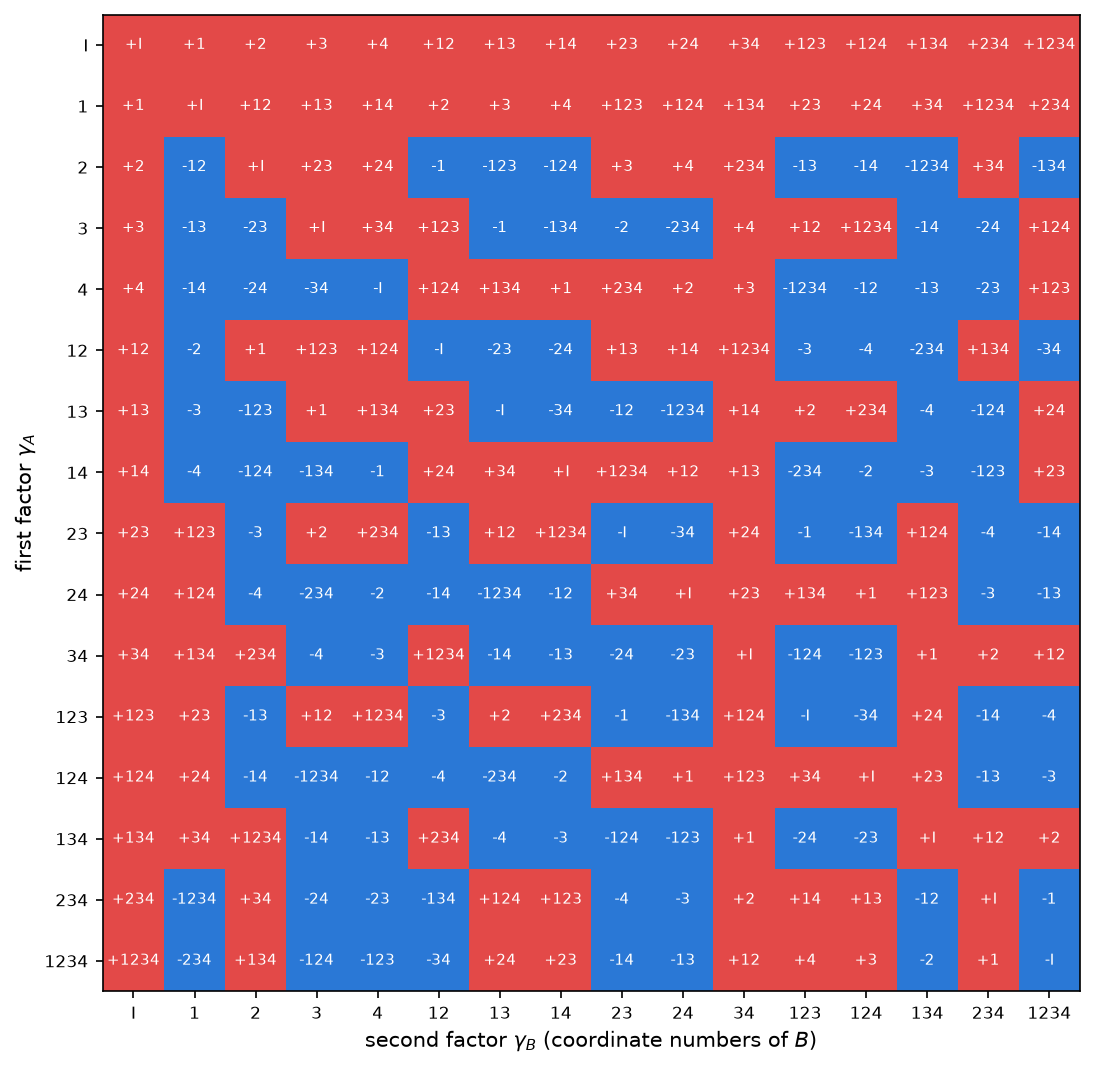

Figure 04c.2 saved as Revision/textbook/figures/04c_2_multiplication_table.png


In [5]:
four = [s for s in SETS if all(a < 4 for a in s)]  # the 16 sets inside x1..x4
table = np.array([[SIGN[INDEX[A], INDEX[B]] for B in four] for A in four])
fig, ax = plt.subplots(figsize=(7.4, 7.0), layout="constrained")
ax.imshow(table, cmap=ListedColormap(["#2a78d6", "#e34948"]),
          norm=BoundaryNorm([-2, 0, 2], 2))
for r, A in enumerate(four):
    for c_, B in enumerate(four):
        name = label(tuple(sorted(set(A) ^ set(B))))
        ax.text(c_, r, ("+" if table[r, c_] > 0 else "-") + name, ha="center",
                va="center", color="white", fontsize=7)
names = [label(s) for s in four]
ax.set_xticks(range(16), names, fontsize=8)
ax.set_yticks(range(16), names, fontsize=8)
ax.set_xlabel("second factor $\\gamma_B$ (coordinate numbers of $B$)")
ax.set_ylabel("first factor $\\gamma_A$")
ax.grid(False)
save_figure(fig, "multiplication_table",
            "The multiplication table of the 16 products of the gammas of 3-space "
            "and time, $\\gamma^{(x_1)}, \\gamma^{(x_2)}, \\gamma^{(x_3)}, "
            "\\gamma^{(x_4)}$: row $\\gamma_A$, column $\\gamma_B$, both named by the "
            "numbers of their coordinates (I is the identity). Each square holds "
            "$\\gamma_A\\gamma_B = \\pm\\gamma_{A \\triangle B}$: the sign (red $+$, "
            "blue $-$) and the name of $A \\triangle B$, the directions in exactly "
            "one of $A$ and $B$. The diagonal holds the squares: $+$I or $-$I, "
            "following rule R2.")

## 7. Rule R2: the squares, and which products are symmetric

The next cell checks rule R2 for all 256 products, counts how many square to
$+I_{16}$ and how many to $-I_{16}$, and checks that a product is symmetric exactly
when its square is $+I_{16}$ (and antisymmetric when it is $-I_{16}$). The reason:
$\gamma_A^T = \gamma_A^{-1}$ (orthogonal), and $\gamma_A^{-1} = \pm\gamma_A$ with the
sign of the square. The symmetric $16 \times 16$ matrices form a space of dimension
$16 \cdot 17/2 = 136$ (the free entries on and above the diagonal) and the
antisymmetric ones a space of dimension $16 \cdot 15/2 = 120$; the counts below fill
both spaces exactly.

In [6]:
rule_r2 = True
square_sign = np.zeros(256, dtype=np.int64)
for i, s in enumerate(SETS):
    k = len(s)
    predicted = (-1) ** (k * (k - 1) // 2)  # // : division without remainder
    for a in s:
        predicted *= eta[a]
    square_sign[i] = predicted
    rule_r2 &= bool((products[i] @ products[i] == predicted * I16).all())
symmetric = np.array([(m.T == m).all() for m in products])
antisymmetric = np.array([(m.T == -m).all() for m in products])
plus, minus = int(np.sum(square_sign == 1)), int(np.sum(square_sign == -1))
report("products with square +I16 and with square -I16", (plus, minus))
check(rule_r2, "gamma_A^2 = (-1)^(k(k-1)/2) prod(eta) I16 for all 256 products")
check(plus == 136 == 16 * 17 // 2 and minus == 120 == 16 * 15 // 2
      and (symmetric == (square_sign == 1)).all()
      and (antisymmetric == (square_sign == -1)).all(),
      "136 products are symmetric (square +I16), 120 antisymmetric (square -I16)")

RESULT products with square +I16 and with square -I16 = (136, 120)
PASS gamma_A^2 = (-1)^(k(k-1)/2) prod(eta) I16 for all 256 products
PASS 136 products are symmetric (square +I16), 120 antisymmetric (square -I16)


The next cell draws, for each degree, how many products square to $+I_{16}$ and how
many to $-I_{16}$, as stacked bars.

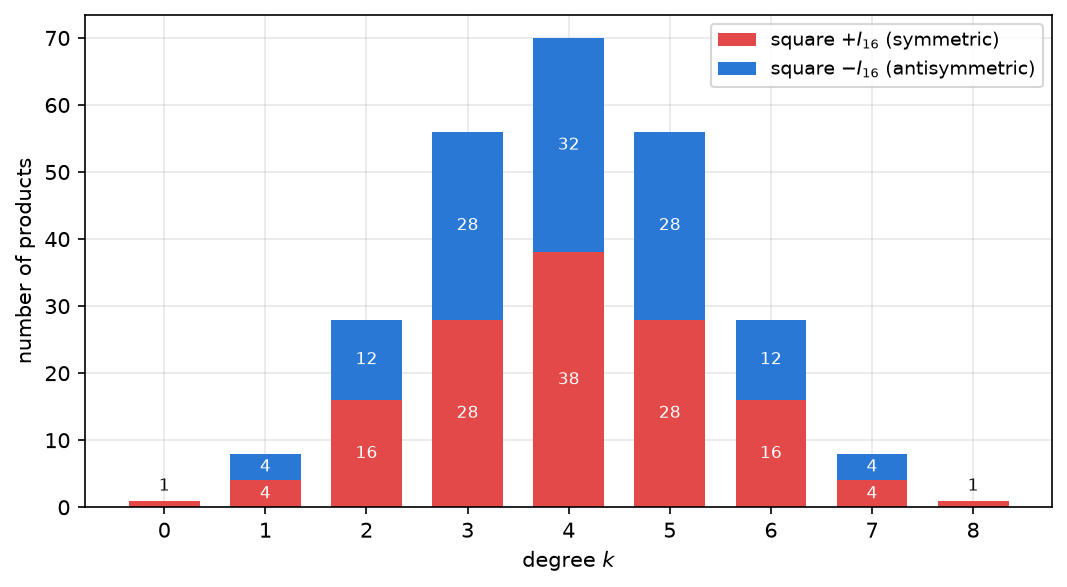

Figure 04c.3 saved as Revision/textbook/figures/04c_3_squares_by_degree.png


In [7]:
plus_by_degree = [int(np.sum((DEGREE == k) & (square_sign == 1))) for k in range(9)]
minus_by_degree = [int(np.sum((DEGREE == k) & (square_sign == -1))) for k in range(9)]
fig, ax = plt.subplots(figsize=(7.0, 3.8), layout="constrained")
ax.set_axisbelow(True)  # grid lines behind the bars
low = ax.bar(range(9), plus_by_degree, color="#e34948", width=0.7,
             label="square $+I_{16}$ (symmetric)")
high = ax.bar(range(9), minus_by_degree, bottom=plus_by_degree, color="#2a78d6",
              width=0.7, label="square $-I_{16}$ (antisymmetric)")
# numbers inside the bars that are tall enough, above the two bars of height 1
ax.bar_label(low, labels=[str(n) if n > 2 else "" for n in plus_by_degree],
             label_type="center", color="white", fontsize=8)
ax.bar_label(high, labels=[str(n) if n else "" for n in minus_by_degree],
             label_type="center", color="white", fontsize=8)
for k in (0, 8):
    ax.text(k, plus_by_degree[k] + 1.5, str(plus_by_degree[k]), ha="center",
            fontsize=8, color="#0b0b0b")
ax.set_xticks(range(9))
ax.set_xlabel("degree $k$")
ax.set_ylabel("number of products")
ax.legend(fontsize=9)
save_figure(fig, "squares_by_degree",
            "The squares of the 256 products by degree $k$ (horizontal axis): red, "
            "the number of products $\\gamma_A$ with $\\gamma_A^2 = +I_{16}$, which "
            "are exactly the symmetric ones; blue, the number with "
            "$\\gamma_A^2 = -I_{16}$, the antisymmetric ones. The sign follows rule "
            "R2: $(-1)^{k(k-1)/2}$ times the signs $\\eta$ of the directions in $A$. "
            "In total 136 = $16 \\cdot 17/2$ symmetric and 120 = $16 \\cdot 15/2$ "
            "antisymmetric products, exactly the dimensions of the symmetric and "
            "antisymmetric $16 \\times 16$ matrices.")

## 8. The trace lemma and the trace products

The next cell checks the trace lemma for the 255 products other than $I_{16}$, and
computes the $256 \times 256$ table of *trace products*
$G_{AB} = \mathrm{tr}(\gamma_A^T\gamma_B)$ (it is called the Gram matrix). The
situation section proved $G = 16\,I_{256}$: every product is perpendicular to every
other one. numpy computes all 65536 entries at once: `flat` holds each product as one
row of 256 numbers, and $\mathrm{tr}(\gamma_A^T\gamma_B) = \sum_{ij}(\gamma_A)_{ij}
(\gamma_B)_{ij}$ is the product of row $A$ of `flat` with row $B$, so
`flat @ flat.T` is the whole table. The cell also computes the table without the
transpose, $\mathrm{tr}(\gamma_A\gamma_B)$, which is $16$ times the sign of the
square on the diagonal and 0 elsewhere.

In [8]:
traces = np.array([np.trace(m) for m in products])
check(traces[0] == 16 and (traces[1:] == 0).all(),
      "trace lemma: tr gamma_A = 0 for all 255 products other than I16")
flat = products.reshape(256, 256)  # each product as one row of 256 entries
gram = flat @ flat.T  # gram[A, B] = tr(gamma_A^T gamma_B), exact whole numbers
# tr(gamma_A gamma_B) = sum_ij (gamma_A)_ij (gamma_B^T)_ij: the same with the
# transposed products in the second factor.
flat_transposed = products.transpose(0, 2, 1).reshape(256, 256)
without_transpose = flat @ flat_transposed.T
check((gram == 16 * np.eye(256, dtype=np.int64)).all(),
      "tr(gamma_A^T gamma_B) = 16 for A = B and 0 otherwise (all 65536 pairs)")
check((without_transpose == 16 * np.diag(square_sign)).all(),
      "tr(gamma_A gamma_B) = 16 times the sign of the square for A = B, else 0")

PASS trace lemma: tr gamma_A = 0 for all 255 products other than I16
PASS tr(gamma_A^T gamma_B) = 16 for A = B and 0 otherwise (all 65536 pairs)
PASS tr(gamma_A gamma_B) = 16 times the sign of the square for A = B, else 0


The next cell draws both tables (divided by 16) as heat maps: on the left the whole
table $\mathrm{tr}(\gamma_A^T\gamma_B)/16$ for the 256 products (numbered 0 to 255 in
the order of degree), on the right a magnified corner of the table
$\mathrm{tr}(\gamma_A\gamma_B)/16$: the 37 products of degree 0, 1 and 2, each named
by the numbers of its coordinates. In the corner one can read off the squares: $+1$
for $I_{16}$ and for the space-like $\gamma^{(x_1)}, \gamma^{(x_2)}, \gamma^{(x_3)},
\gamma^{(x_8)}$, $-1$ for the time-like ones, and for a product of two gammas
$(\gamma^a\gamma^b)^2 = -\eta^{aa}\eta^{bb}$ (rule R2 with $k = 2$).

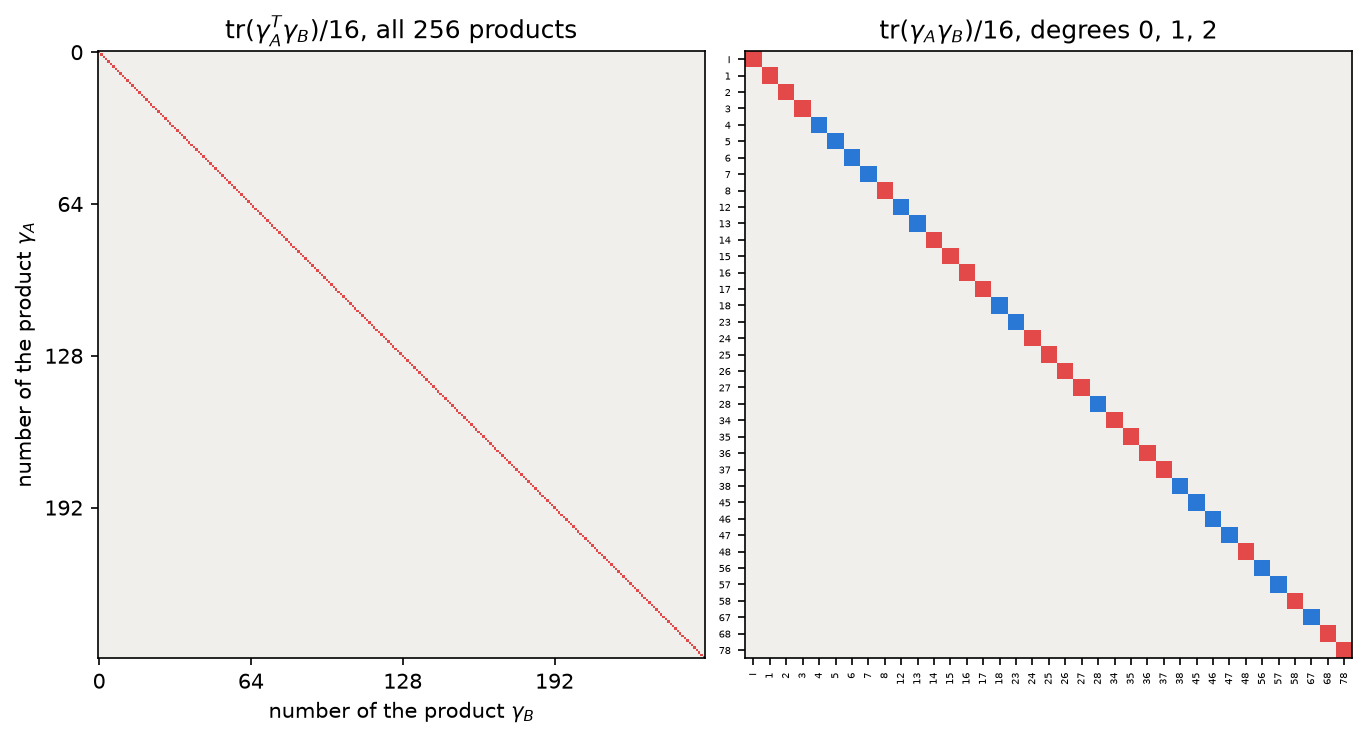

Figure 04c.4 saved as Revision/textbook/figures/04c_4_trace_products.png


In [9]:
starts = [int(np.argmax(DEGREE == k)) for k in range(9)]  # first product of degree k
three = ListedColormap(["#2a78d6", "#f0efec", "#e34948"])  # -1, 0, +1
three_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 4.8), layout="constrained")
left.imshow(gram // 16, cmap=three, norm=three_norm, interpolation="nearest")
left.set_xticks(range(0, 256, 64))
left.set_yticks(range(0, 256, 64))
left.set_xlabel("number of the product $\\gamma_B$")
left.set_ylabel("number of the product $\\gamma_A$")
left.set_title("$\\mathrm{tr}(\\gamma_A^T\\gamma_B)/16$, all 256 products")
left.grid(False)
corner = starts[3]  # 37: the products of degree 0, 1 and 2
right.imshow(without_transpose[:corner, :corner] // 16, cmap=three, norm=three_norm)
names = [label(s) for s in SETS[:corner]]
right.set_xticks(range(corner), names, fontsize=5, rotation=90)
right.set_yticks(range(corner), names, fontsize=5)
right.set_title("$\\mathrm{tr}(\\gamma_A\\gamma_B)/16$, degrees 0, 1, 2")
right.grid(False)
save_figure(fig, "trace_products",
            "The trace products of the products of the author's gammas (red $+1$, "
            "blue $-1$, grey $0$). Left: "
            "$\\mathrm{tr}(\\gamma_A^T\\gamma_B)/16$ for all 256 products, numbered "
            "0 to 255 in the order of their degree; it is 1 on the diagonal and 0 "
            "everywhere else, so the 256 products are perpendicular to each other "
            "and therefore independent. Right: a magnified corner of "
            "$\\mathrm{tr}(\\gamma_A\\gamma_B)/16$, the 37 products of degree 0, 1 "
            "and 2 named by their coordinate numbers (I is the identity); it is "
            "zero off the diagonal, and its diagonal shows the square of each "
            "product: $+1$ for I, 1, 2, 3, 8, $-1$ for 4, 5, 6, 7, and "
            "$-\\eta^{aa}\\eta^{bb}$ for a product $\\gamma^a\\gamma^b$.")

## 9. Linear independence: exact rank 256

The trace argument already proves independence. The Revision record computed the
rank directly, by exact elimination with fractions. The next cell does the same with
sympy's `DomainMatrix` over the rational numbers QQ (exact fractions, no rounding):
the 256 products, each written as a row of 256 numbers, have rank 256. It also checks
that the rank appears in the detail texts of the two Revision checks, exactly as they
state it.

In [10]:
WOLFRAM = "Revision/algebra/reports/wolfram-algebra.json"
PYTHON = "Revision/algebra/reports/python-algebra.json"
RECORDED = {}
for report_file in (WOLFRAM, PYTHON):
    text = repository_file(report_file).read_text(encoding="utf-8")
    RECORDED[report_file] = {e["name"]: e for e in json.loads(text)["checks"]}


def recorded(report_file, name):
    """The detail text of a Revision check; it must be recorded as passed."""
    entry = RECORDED[report_file][name]
    if entry["verdict"].upper() != "PASS":
        raise AssertionError(f"{report_file}: {name} is not recorded as passed")
    return entry["detail"]


def exact_rank(rows):
    """The exact rank of a list of rows of whole numbers (fractions, over QQ)."""
    matrix = DomainMatrix([[sp.ZZ(int(x)) for x in row] for row in rows],
                          (len(rows), len(rows[0])), sp.ZZ)
    return matrix.convert_to(sp.QQ).rank()


rank_all = exact_rank(flat.tolist())
report("exact rank of the 256 products", rank_all)
check(rank_all == 256
      and f"span dimension {rank_all} = 16^2" in recorded(
          WOLFRAM, "Clifford_basis_spans_full_matrix_algebra")
      and f"{rank_all} (sympy DomainMatrix over QQ)" in recorded(
          PYTHON, "clifford_products_span_M16"),
      "the 256 products are independent: Cl(4,4) is all real 16 x 16 matrices")
print(f"     reproduces {WOLFRAM}")
print("         check Clifford_basis_spans_full_matrix_algebra")
print(f"     reproduces {PYTHON}")
print("         check clifford_products_span_M16")

RESULT exact rank of the 256 products = 256
PASS the 256 products are independent: Cl(4,4) is all real 16 x 16 matrices
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check Clifford_basis_spans_full_matrix_algebra
     reproduces Revision/algebra/reports/python-algebra.json
         check clifford_products_span_M16


## 10. Every matrix is a combination of the products

Because the products are a basis, every real $16 \times 16$ matrix $M$ equals
$\sum_A c_A\gamma_A$, and the trace products give the coefficients:
$c_A = \mathrm{tr}(\gamma_A^T M)/16$ (multiply $M = \sum_B c_B\gamma_B$ by
$\gamma_A^T$ and take the trace). The next cell does this for two examples: the
matrix $E_{00}$ with a single 1 in row 0 and column 0, and a matrix of random whole
numbers between $-3$ and $3$ (seed 12345). It computes $16\,c_A$ (whole numbers, so
the arithmetic stays exact), rebuilds $16M = \sum_A (16c_A)\gamma_A$ and checks that
it is exactly $16M$. For $E_{00}$ only 16 coefficients are nonzero, each $\pm 1/16$:
they belong to the 16 products that are diagonal matrices.

In [11]:
e00 = np.zeros((16, 16), dtype=np.int64)
e00[0, 0] = 1
generator = np.random.default_rng(12345)
random_matrix = generator.integers(-3, 4, size=(16, 16))  # whole numbers -3..3
coefficients = {}
for name, matrix in (("E00", e00), ("random", random_matrix)):
    sixteen_c = flat @ matrix.reshape(256)  # 16 c_A = tr(gamma_A^T M) for all A
    rebuilt = np.einsum("a,aij->ij", sixteen_c, products)  # sum_A (16 c_A) gamma_A
    coefficients[name] = sixteen_c / 16.0
    check((rebuilt == 16 * matrix).all(),
          f"the matrix {name} equals sum_A c_A gamma_A with c_A = tr(gamma_A^T M)/16")
nonzero = [label(SETS[i]) for i in np.flatnonzero(coefficients["E00"])]
diagonal = [label(s) for i, s in enumerate(SETS)
            if (products[i] == np.diag(np.diag(products[i]))).all()]
say("the nonzero coefficients of E00 belong to: " + ", ".join(nonzero))
check(nonzero == diagonal and len(nonzero) == 16
      and set(np.abs(coefficients["E00"][np.flatnonzero(coefficients["E00"])]))
      == {1 / 16},
      "E00 has 16 coefficients +-1/16, on the 16 diagonal products")

PASS the matrix E00 equals sum_A c_A gamma_A with c_A = tr(gamma_A^T M)/16
PASS the matrix random equals sum_A c_A gamma_A with c_A = tr(gamma_A^T M)/16
the nonzero coefficients of E00 belong to: I, 16, 25, 34, 78, 1256, 1346, 1678, 2345,
    2578, 3478, 123456, 125678, 134678, 234578, 12345678
PASS E00 has 16 coefficients +-1/16, on the 16 diagonal products


The next cell draws the 256 coefficients of both examples, product number on the
horizontal axis (ordered by degree as before).

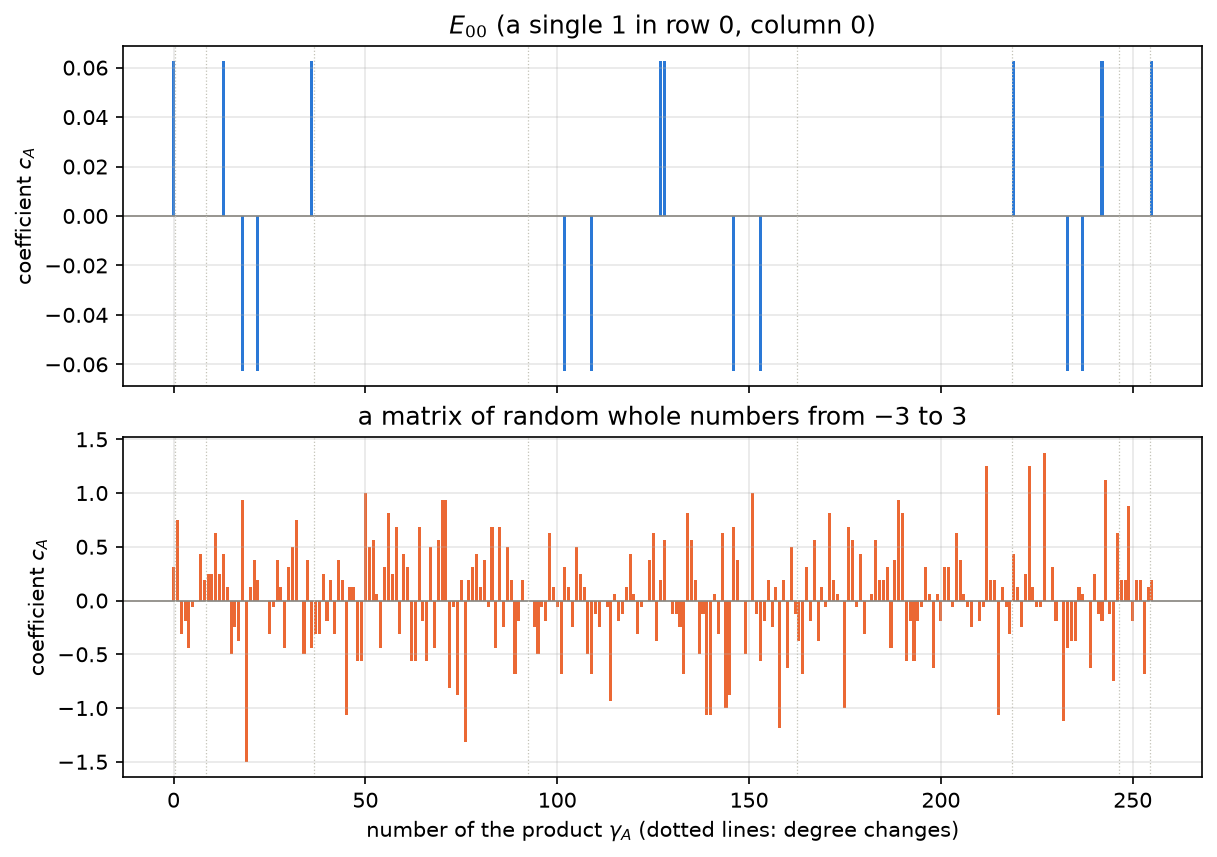

Figure 04c.5 saved as Revision/textbook/figures/04c_5_coefficients.png


In [12]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(8.0, 5.6), layout="constrained",
                                  sharex=True)
for ax, name, colour in ((top, "E00", "#2a78d6"), (bottom, "random", "#eb6834")):
    ax.bar(range(256), coefficients[name], color=colour, width=0.8)
    ax.axhline(0.0, color="#898781", linewidth=0.8)
    ax.set_ylabel("coefficient $c_A$")
    for start in starts[1:]:
        ax.axvline(start - 0.5, color="#c3c2b7", linewidth=0.6, linestyle=":")
top.set_title("$E_{00}$ (a single 1 in row 0, column 0)")
bottom.set_title("a matrix of random whole numbers from $-3$ to $3$")
bottom.set_xlabel("number of the product $\\gamma_A$ (dotted lines: degree changes)")
save_figure(fig, "coefficients",
            "Every real $16 \\times 16$ matrix is a combination "
            "$\\sum_A c_A\\gamma_A$ of the 256 products, with "
            "$c_A = \\mathrm{tr}(\\gamma_A^T M)/16$; horizontal axis the number of "
            "the product (ordered by degree, dotted lines where the degree changes), "
            "vertical axis the coefficient $c_A$ (pure numbers). Top: the matrix "
            "$E_{00}$ with a single entry 1 needs only the 16 products that are "
            "diagonal matrices, each with coefficient $\\pm 1/16$. Bottom: a matrix "
            "of random whole numbers needs almost all 256 products.")

## 11. Even products fill the diagonal blocks, odd products the others

Every gamma has zero upper-left and lower-right $8 \times 8$ blocks (it is block
off-diagonal). By the block rule a product of two block off-diagonal matrices is
block diagonal, and a product of a block diagonal and a block off-diagonal matrix is
block off-diagonal. So every even product is block diagonal and every odd one block
off-diagonal. The block diagonal real matrices form a space of dimension
$64 + 64 = 128$ and so do the block off-diagonal ones; the 128 even products are
independent (they are part of the 256), so they span all block diagonal matrices
(Mat(8) + Mat(8)), and the odd ones all block off-diagonal matrices. The next cell
checks the block forms and the two exact ranks, reproduces the Revision record, and
counts at every position $(i, j)$ how many even (and odd) products have a nonzero
entry there.

In [13]:
even, odd = flat[DEGREE % 2 == 0], flat[DEGREE % 2 == 1]  # rows of 256 numbers
even_blocks = all((m[:8, 8:] == 0).all() and (m[8:, :8] == 0).all()
                  for m in products[DEGREE % 2 == 0])
odd_blocks = all((m[:8, :8] == 0).all() and (m[8:, 8:] == 0).all()
                 for m in products[DEGREE % 2 == 1])
rank_even, rank_odd = exact_rank(even.tolist()), exact_rank(odd.tolist())
report("exact ranks of the even and of the odd products", (rank_even, rank_odd))
check(even_blocks and odd_blocks and rank_even == 128 and rank_odd == 128
      and f"dimension {rank_even} = 2 x 8^2" in recorded(
          WOLFRAM, "even_subalgebra_dimension")
      and f"rank {rank_even} (Fraction), {rank_even} (sympy)" in recorded(
          PYTHON, "even_products_span_M8_plus_M8"),
      "even products block diagonal, odd block off-diagonal, ranks 128 and 128")
print(f"     reproduces {WOLFRAM}")
print("         check even_subalgebra_dimension")
print(f"     reproduces {PYTHON}")
print("         check even_products_span_M8_plus_M8")
support_even = np.sum(products[DEGREE % 2 == 0] != 0, axis=0)  # count per entry
support_odd = np.sum(products[DEGREE % 2 == 1] != 0, axis=0)
report("even products nonzero at each position (values found)",
       sorted(set(int(x) for x in support_even.flatten())))
upper = np.arange(16) < 8  # True for the rows (and columns) 0 to 7
# in_diagonal_blocks[i, j] is True when row i and column j lie in the same half;
# ~ turns True into False and back.
in_diagonal_blocks = np.equal.outer(upper, upper)
check((support_even[in_diagonal_blocks] == 16).all()
      and (support_even[~in_diagonal_blocks] == 0).all()
      and (support_odd[~in_diagonal_blocks] == 16).all()
      and (support_odd[in_diagonal_blocks] == 0).all(),
      "each position of its blocks is covered by exactly 16 even (or odd) products")

RESULT exact ranks of the even and of the odd products = (128, 128)
PASS even products block diagonal, odd block off-diagonal, ranks 128 and 128
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check even_subalgebra_dimension
     reproduces Revision/algebra/reports/python-algebra.json
         check even_products_span_M8_plus_M8
RESULT even products nonzero at each position (values found) = [0, 16]
PASS each position of its blocks is covered by exactly 16 even (or odd) products


The next cell draws these two counts as heat maps.

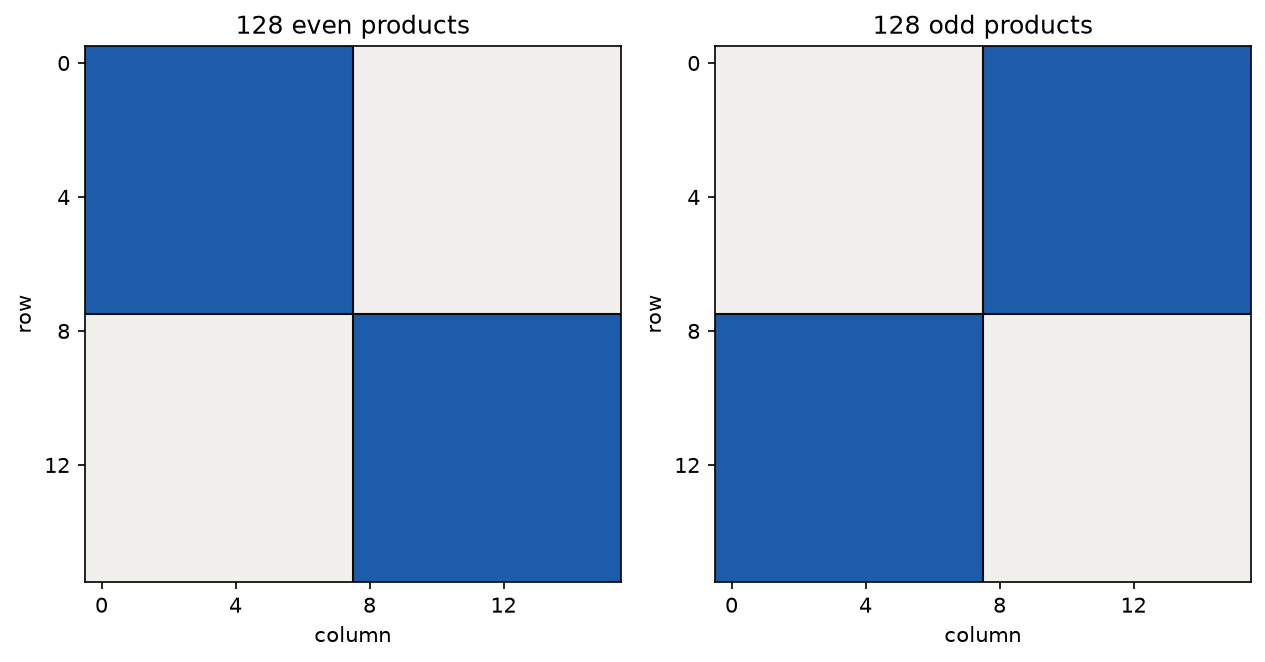

Figure 04c.6 saved as Revision/textbook/figures/04c_6_even_odd_blocks.png


In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(8.4, 4.2), layout="constrained")
cover = ListedColormap(["#f0efec", "#1c5cab"])  # 0 products, 16 products
for ax, values, title in ((left, support_even, "128 even products"),
                          (right, support_odd, "128 odd products")):
    ax.imshow(values, cmap=cover, norm=BoundaryNorm([-1, 8, 17], 2))
    ax.set_xticks(range(0, 16, 4))
    ax.set_yticks(range(0, 16, 4))
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.axhline(7.5, color="#0b0b0b", linewidth=1)
    ax.axvline(7.5, color="#0b0b0b", linewidth=1)
    ax.grid(False)
save_figure(fig, "even_odd_blocks",
            "Where the products live: for every position (row and column 0 to 15) "
            "the number of products with a nonzero entry there (dark blue 16, light "
            "grey 0). Left: the 128 even products cover exactly the two diagonal "
            "$8 \\times 8$ blocks, each position 16 times; they span all block "
            "diagonal matrices, Mat(8) + Mat(8). Right: the 128 odd products cover "
            "exactly the two other blocks. Black lines separate the blocks.")

## 12. How big must the matrices be?

The next cell compares four examples of matrices with a Clifford relation:

- $n = 2$: the real $2 \times 2$ matrices $\sigma_x$ and $N$ (signs $+1, -1$);
- $n = 4$: Dirac's complex $4 \times 4$ matrices (rebuilt here in three lines);
- $n = 7$: the author's seven $8 \times 8$ matrices tau[1], ..., tau[7], which are the
  lower-left $8 \times 8$ blocks of $\gamma^{(x_1)}, \dots, \gamma^{(x_7)}$ (his
  construction puts tau[k] there);
- $n = 8$: the author's gammas.

For each it computes the number $2^n$ of products, their exact rank and the
dimension $d^2$ of the space of all $d \times d$ matrices. For the even $n$ the rank
is $2^n = d^2$: the products fill everything, and $d$ is as small as possible. For
the odd $n = 7$ the trace lemma fails: the product of all seven taus is $I_8$, so the
products come in pairs that are equal up to sign, and only $64 = 8^2$ of the 128 are
independent. This is why seven anticommuting matrices fit into $8 \times 8$ matrices
but eight need $16 \times 16$.

In [15]:
def all_products(generators):
    """The 2^n ordered products of a list of square sympy matrices."""
    size = generators[0].shape[0]
    result = []
    for k in range(len(generators) + 1):
        for s in itertools.combinations(range(len(generators)), k):
            matrix = sp.eye(size)
            for a in s:
                matrix = matrix * generators[a]
            result.append(matrix)
    return result


sigma_x, sigma_y = sp.Matrix([[0, 1], [1, 0]]), sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma_z, N_matrix = sp.Matrix([[1, 0], [0, -1]]), sp.Matrix([[0, 1], [-1, 0]])
Z2, I2 = sp.zeros(2, 2), sp.eye(2)
dirac = [sp.Matrix(sp.BlockMatrix([[I2, Z2], [Z2, -I2]]))] + [
    sp.Matrix(sp.BlockMatrix([[Z2, s], [-s, Z2]])) for s in (sigma_x, sigma_y, sigma_z)]
taus = [sp.Matrix(gamma[a][8:, :8].tolist()) for a in range(7)]  # tau[1..7]
examples = {"n = 2, real 2 x 2": [sigma_x, N_matrix], "n = 4, Dirac 4 x 4": dirac,
            "n = 7, tau 8 x 8": taus, "n = 8, gammas 16 x 16":
                [sp.Matrix(g.tolist()) for g in gamma]}
rows = []
for name, generators in examples.items():
    prods = all_products(generators)
    d = generators[0].shape[0]
    flat_rows = sp.Matrix([list(m) for m in prods])  # one row per product
    # exact rank; from_Matrix chooses exact numbers (Gaussian integers for Dirac)
    rank = DomainMatrix.from_Matrix(flat_rows).rank()
    rows.append((name, len(prods), rank, d * d))
    print(f"{name:24} products {len(prods):4d}   rank {rank:4d}   d^2 {d * d:4d}")
tau_product = sp.eye(8)
for t in taus:
    tau_product = tau_product * t
check([r[2] for r in rows] == [4, 16, 64, 256] and [r[1] for r in rows]
      == [4, 16, 128, 256], "ranks 4, 16, 64, 256: products fill d^2 for even n")
check(tau_product == sp.eye(8) and taus[6] == sp.diag(-1, -1, -1, -1, 1, 1, 1, 1)
      and "tau[7] = diag(-I4, I4) and tau[1]...tau[7] = ID8"
      in recorded(PYTHON, "tau7_and_product"),
      "tau[1] tau[2] ... tau[7] = I8 and tau[7] = diag(-I4, I4)")
print(f"     reproduces {PYTHON}")
print("         check tau7_and_product")

n = 2, real 2 x 2        products    4   rank    4   d^2    4
n = 4, Dirac 4 x 4       products   16   rank   16   d^2   16
n = 7, tau 8 x 8         products  128   rank   64   d^2   64
n = 8, gammas 16 x 16    products  256   rank  256   d^2  256
PASS ranks 4, 16, 64, 256: products fill d^2 for even n
PASS tau[1] tau[2] ... tau[7] = I8 and tau[7] = diag(-I4, I4)
     reproduces Revision/algebra/reports/python-algebra.json
         check tau7_and_product


The next cell draws the three numbers of each example as grouped bars on a
logarithmic scale (base 2).

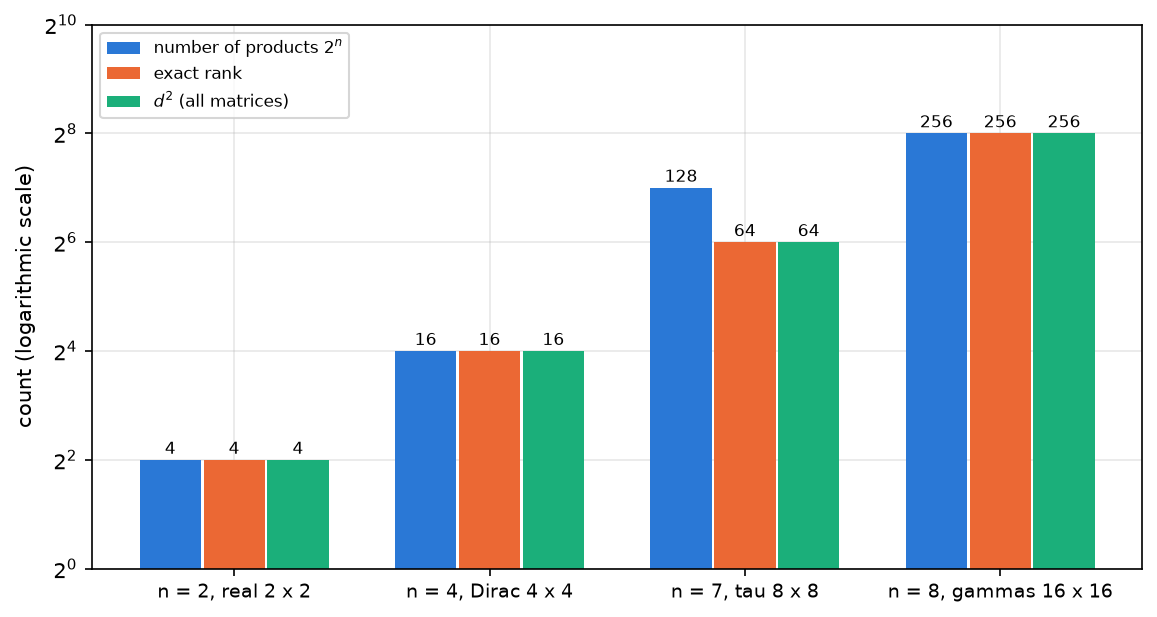

Figure 04c.7 saved as Revision/textbook/figures/04c_7_how_big.png


In [16]:
fig, ax = plt.subplots(figsize=(7.6, 4.0), layout="constrained")
ax.set_axisbelow(True)  # grid lines behind the bars
positions = np.arange(len(rows))
for offset, column, colour, name in ((-0.25, 1, "#2a78d6", "number of products $2^n$"),
                                     (0.0, 2, "#eb6834", "exact rank"),
                                     (0.25, 3, "#1baf7a", "$d^2$ (all matrices)")):
    values = [r[column] for r in rows]
    bars = ax.bar(positions + offset, values, width=0.24, color=colour, label=name)
    ax.bar_label(bars, labels=[str(v) for v in values], fontsize=8, padding=1)
ax.set_yscale("log", base=2)
ax.set_ylim(1, 1024)
ax.set_xticks(positions, [r[0] for r in rows], fontsize=9)
ax.set_ylabel("count (logarithmic scale)")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "how_big",
            "Why eight gammas need $16 \\times 16$ matrices: for four examples of "
            "$n$ matrices of size $d \\times d$ with a Clifford relation, the number "
            "$2^n$ of their ordered products (blue), the exact rank of these "
            "products (orange) and the dimension $d^2$ of the space of all "
            "$d \\times d$ matrices (green), on a logarithmic scale. For even $n$ "
            "(2, 4, 8) all three are equal: the products are independent and fill "
            "all matrices, so $d$ cannot be smaller. For the odd $n = 7$ (the "
            "author's $8 \\times 8$ tau matrices) the 128 products have rank only "
            "64 = $8^2$, because the product of all seven is the identity.")

## 13. The 28 products of two different gammas

The products of degree 2, $\gamma^a\gamma^b$ with $a$ before $b$ in the order
$x_1, \dots, x_8$, are $\binom{8}{2} = 28$ matrices. Half of each of them is a matrix
that the Revision record names $S^{ab}$:
$S^{ab} = \tfrac14(\gamma^a\gamma^b - \gamma^b\gamma^a)$. Line by line, for
$a \neq b$: $\gamma^b\gamma^a = -\gamma^a\gamma^b$ (two different gammas
anticommute), so $\gamma^a\gamma^b - \gamma^b\gamma^a = 2\gamma^a\gamma^b$, and
$S^{ab} = \tfrac14 \cdot 2\gamma^a\gamma^b = \tfrac12\gamma^a\gamma^b$. For $a = b$
the two terms cancel and $S^{aa} = 0$. The matrices $S^{ab}$ are the generators of
the rotations and boosts of the 16-component field (the record checks that they
obey the rules of the rotations and boosts of the 4+4 space-time).

By rule R2 with $k = 2$, $(\gamma^a\gamma^b)^2 = -\eta^{aa}\eta^{bb} I_{16}$. Two
directions of the same kind (both space-like or both time-like) have
$\eta^{aa}\eta^{bb} = +1$, so their product squares to $-I_{16}$, like the
imaginary unit $i$ of the complex numbers: there are
$\binom{4}{2} + \binom{4}{2} = 12$ such pairs, the planes of *rotations*. A
space-like and a time-like direction have $\eta^{aa}\eta^{bb} = -1$, so their
product squares to $+I_{16}$: there are $4 \cdot 4 = 16$ such pairs, the planes of
*boosts*.

The next cell checks, exactly: $\tfrac14(\gamma^a\gamma^b - \gamma^b\gamma^a)$ is
$\tfrac12\gamma^a\gamma^b$ for $a \neq b$ and 0 for $a = b$; it compares all
$8 \times 8 = 64$ matrices $S^{ab}$ (16384 entries) with the matrices that the
Revision record file `Revision/algebra/gammas.json` stores under the key S (their
entries are 0 and the fractions $\pm 1/2$, written as texts "1/2" and "-1/2");
and it checks the squares and the 12 + 16 count. All arithmetic is exact: the
fractions are Python `Fraction` numbers.

In [17]:
from fractions import Fraction  # exact fractions such as 1/2


def exact(entry):
    """A number of gammas.json: a JSON integer or a text "p/q", as a Fraction."""
    if isinstance(entry, int):
        return Fraction(entry)
    numerator, denominator = entry.split("/")
    return Fraction(int(numerator), int(denominator))


PAIRS_AB = [(a, b) for a in range(8) for b in range(a + 1, 8)]  # the 28 pairs
two = {(a, b): products[INDEX[(a, b)]] for a, b in PAIRS_AB}  # gamma^a gamma^b
half_ok, record_ok, values = True, True, set()
for a, b in itertools.product(range(8), repeat=2):  # all 64 ordered pairs
    ab, ba = gamma[a] @ gamma[b], gamma[b] @ gamma[a]
    commutator = ab - ba  # 4 S^ab, a whole-number matrix
    if a != b:
        half_ok &= bool((commutator == 2 * ab).all())  # 4 S^ab = 2 gamma^a gamma^b
    else:
        half_ok &= not commutator.any()  # S^aa = 0
    stored = record["S"][a][b]  # the record's S^ab: 16 rows of exact numbers
    for i, j in itertools.product(range(16), repeat=2):
        ours = Fraction(int(commutator[i, j]), 4)  # S^ab entry, exact
        values.add(ours)
        record_ok &= exact(stored[i][j]) == ours
report("the different entries of the 64 matrices S^ab",
       [str(v) for v in sorted(values)])
check(half_ok and record_ok and sorted(values) == [Fraction(-1, 2), 0,
                                                   Fraction(1, 2)]
      and "(1/2) gamma^a gamma^b for a != b" in recorded(PYTHON, "S_definition")
      and "S^ab = (1/2) gamma^a gamma^b" in recorded(WOLFRAM, "S_half_product")
      and "{-1/2, 0, 1/2}" in recorded(WOLFRAM, "S_real_entries_in_half_integers"),
      "S^ab = (1/4)(g^a g^b - g^b g^a) = (1/2) g^a g^b = the record's S, entry by entry")
print(f"     reproduces {PYTHON}")
print("         check S_definition")
print(f"     reproduces {WOLFRAM}")
print("         checks S_half_product, S_real_entries_in_half_integers")
square_of = {pair: int((m @ m)[0, 0]) for pair, m in two.items()}  # +1 or -1
rotations = [pair for pair in PAIRS_AB if square_of[pair] == -1]
boosts = [pair for pair in PAIRS_AB if square_of[pair] == 1]
report("pairs whose product squares to -I16 (rotations), to +I16 (boosts)",
       (len(rotations), len(boosts)))
check(all((m @ m == square_of[(a, b)] * I16).all()
          and square_of[(a, b)] == -eta[a] * eta[b]
          and not m[:8, 8:].any() and not m[8:, :8].any()
          for (a, b), m in two.items())
      and len(rotations) == 12 and len(boosts) == 16,
      "(g^a g^b)^2 = -eta^aa eta^bb I16; 12 rotation, 16 boost planes; block diagonal")

RESULT the different entries of the 64 matrices S^ab = ['-1/2', '0', '1/2']
PASS S^ab = (1/4)(g^a g^b - g^b g^a) = (1/2) g^a g^b = the record's S, entry by entry
     reproduces Revision/algebra/reports/python-algebra.json
         check S_definition
     reproduces Revision/algebra/reports/wolfram-algebra.json
         checks S_half_product, S_real_entries_in_half_integers
RESULT pairs whose product squares to -I16 (rotations), to +I16 (boosts) = (12, 16)
PASS (g^a g^b)^2 = -eta^aa eta^bb I16; 12 rotation, 16 boost planes; block diagonal


The next cell draws the 28 products as a triangular table of heat maps: the panel
in row $x_a$ and column $x_b$ shows $\gamma^a\gamma^b$ (rows $x_1$ to $x_7$, columns
$x_2$ to $x_8$; the panels on the diagonal of the grid show $x_1x_2, x_2x_3, \dots,
x_7x_8$, and the panels below it stay empty). A black frame
marks a rotation plane (square $-I_{16}$), a green frame a boost plane (square
$+I_{16}$).

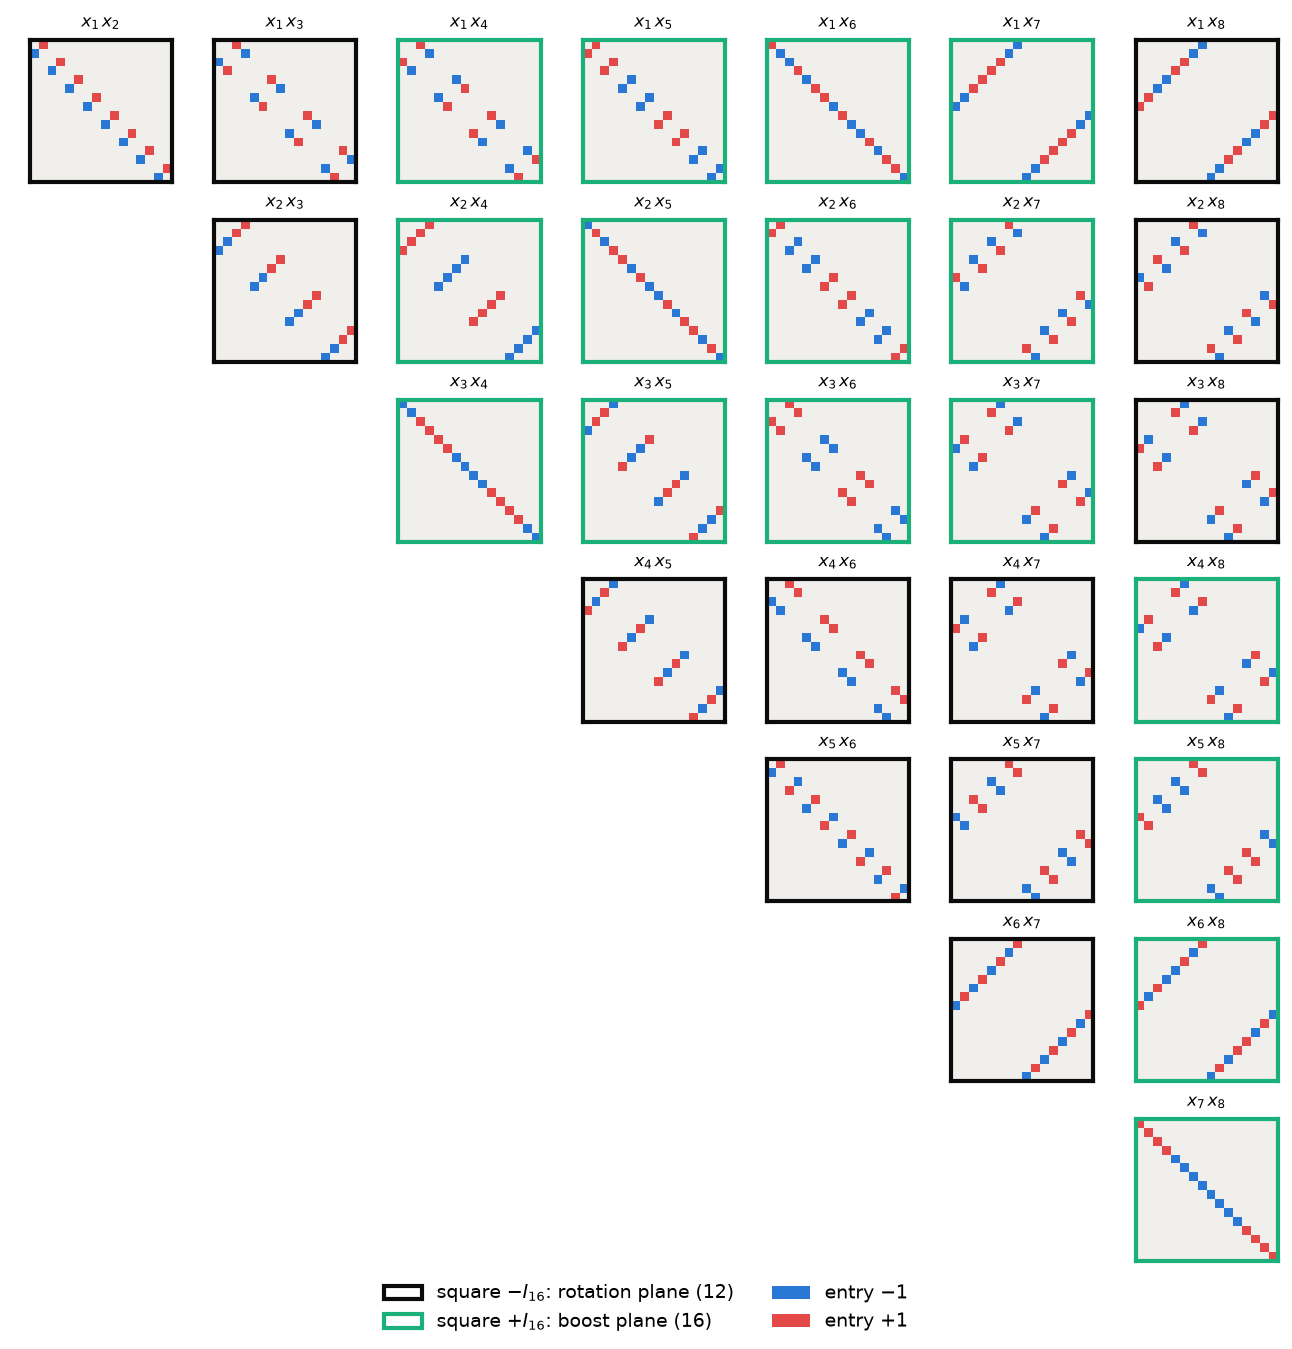

Figure 04c.8 saved as Revision/textbook/figures/04c_8_two_gamma_products.png


In [18]:
from matplotlib.patches import Patch  # coloured squares for the key

FRAME = {-1: "#0b0b0b", 1: "#1baf7a"}  # square -I16: black, square +I16: green
fig, axes = plt.subplots(7, 7, figsize=(8.6, 8.9), layout="constrained")
for r, c_ in itertools.product(range(7), repeat=2):
    ax = axes[r, c_]
    a, b = r, c_ + 1  # row: first factor x_(a+1); column: second factor x_(b+1)
    if b <= a:
        ax.axis("off")  # no panel below the diagonal of the grid (c_ < r)
        continue
    ax.imshow(two[(a, b)], cmap=three, norm=three_norm)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():  # the frame of the panel
        spine.set_edgecolor(FRAME[square_of[(a, b)]])
        spine.set_linewidth(2.0)
    ax.set_title(f"$x_{a + 1}\\,x_{b + 1}$", fontsize=8)
key = [Patch(facecolor="white", edgecolor=FRAME[-1], linewidth=2,
             label="square $-I_{16}$: rotation plane (12)"),
       Patch(facecolor="white", edgecolor=FRAME[1], linewidth=2,
             label="square $+I_{16}$: boost plane (16)"),
       Patch(facecolor="#2a78d6", label="entry $-1$"),
       Patch(facecolor="#e34948", label="entry $+1$")]
fig.legend(handles=key, loc="outside lower center", ncol=2, fontsize=9,
           frameon=False)
save_figure(fig, "two_gamma_products",
            "The 28 products $\\gamma^a\\gamma^b$ of two different gammas of the "
            "author, each drawn as a $16 \\times 16$ heat map (blue $-1$, grey $0$, "
            "red $+1$); the panel titled $x_a x_b$ shows $\\gamma^a\\gamma^b$, with "
            "$x_a$ before $x_b$ in the order $x_1$ to $x_8$. Every product is block "
            "diagonal, with its 16 nonzero entries in the two diagonal "
            "$8 \\times 8$ blocks. Black frames mark the 12 products that square to "
            "$-I_{16}$ (two directions of the same kind: rotation planes), green "
            "frames the 16 that square to $+I_{16}$ (one space-like and one "
            "time-like direction: boost planes). Half of each product is the "
            "matrix $S^{ab}$ of the Revision record.")

## 14. The last check

The last cell checks that the eight figure files exist in the folder
`Revision/textbook/figures` and prints the number of checks that passed.

In [19]:
names = ["04c_1_products_by_degree.png", "04c_2_multiplication_table.png",
         "04c_3_squares_by_degree.png", "04c_4_trace_products.png",
         "04c_5_coefficients.png", "04c_6_even_odd_blocks.png", "04c_7_how_big.png",
         "04c_8_two_gamma_products.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in names),
      "all eight figure files exist")
all_checks_passed()

PASS all eight figure files exist
ALL 19 CHECKS PASSED (notebook 04c)


## 15. What this notebook showed

- PROVED (exact integer arithmetic, all pairs checked): the 256 ordered products of
  the author's gammas multiply by rule R1,
  $\gamma_A\gamma_B = s(A,B)\gamma_{A\triangle B}$; they square to $\pm I_{16}$ by
  rule R2; 136 are symmetric (square $+I_{16}$) and 120 antisymmetric (square
  $-I_{16}$); every product other than $I_{16}$ has trace 0, and
  $\mathrm{tr}(\gamma_A^T\gamma_B) = 16\delta_{AB}$.
- PROVED (exact rank over the rational numbers; reproduces
  `Revision/algebra/reports/wolfram-algebra.json`, check
  `Clifford_basis_spans_full_matrix_algebra`, and `python-algebra.json`, check
  `clifford_products_span_M16`): the 256 products are independent, so the Clifford
  algebra Cl(4,4) of the author's gammas is the set of all real $16 \times 16$
  matrices, and every matrix is $\sum_A c_A\gamma_A$ with
  $c_A = \mathrm{tr}(\gamma_A^T M)/16$.
- PROVED (reproduces the checks `even_subalgebra_dimension` and
  `even_products_span_M8_plus_M8`): the 128 even products are block diagonal and
  span all block diagonal matrices (dimension 128); the 128 odd products span the
  block off-diagonal ones.
- PROVED: eight $d \times d$ matrices with a Clifford relation have $d \ge 16$
  ($d^2 \ge 2^8$); the author's field has exactly 16 components. Seven such
  matrices fit into $8 \times 8$ (the author's tau matrices, whose product is
  $I_8$; reproduces check `tau7_and_product`).
- PROVED (exact fractions; reproduces `python-algebra.json`, check `S_definition`,
  and `wolfram-algebra.json`, checks `S_half_product` and
  `S_real_entries_in_half_integers`, and agrees entry by entry with the matrices S
  of `Revision/algebra/gammas.json`): $S^{ab} = \tfrac14(\gamma^a\gamma^b -
  \gamma^b\gamma^a) = \tfrac12\gamma^a\gamma^b$ for $a \neq b$, with entries
  $0, \pm\tfrac12$. The 28 products of two gammas are block diagonal; 12 square to
  $-I_{16}$ (rotation planes) and 16 to $+I_{16}$ (boost planes).
- ASSUMED: nothing beyond the Clifford relation of the author's gammas, which the
  Revision record verified exactly. These are statements of algebra; they make no
  physical claim.